# Solução MEF

In [ ]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

--2026-03-16 19:50:40--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-03-16 19:50:40 (52.9 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/7e396ce3/releases/pybi

In [ ]:
from __future__ import print_function
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt
%matplotlib inline

Simulação concluída! Arquivo salvo em 'resultado_cilindro/deslocamento.pvd'.


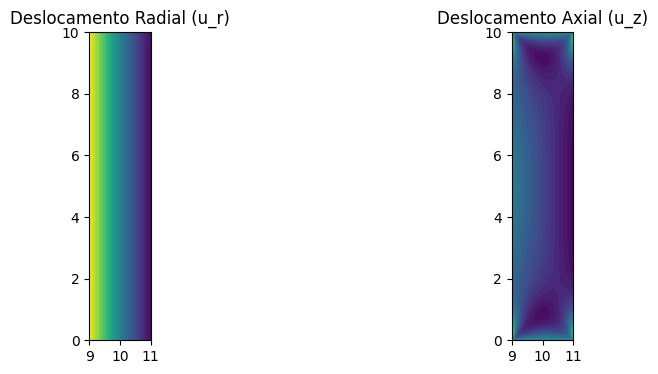

In [42]:
from dolfin import *
import matplotlib.pyplot as plt

def simular_vaso_pressao():
    # =========================================
    # 1. PARÂMETROS DO PROBLEMA
    # =========================================
    R_int = 9.0   # Raio interno (m)
    R_ext = 11.0  # Raio externo (m)
    H = 10.0      # Altura do trecho do cilindro (m)

    E = 200e9     # Módulo de Young (Aço: 200 GPa)
    nu = 0.3      # Coeficiente de Poisson
    P_int = 10e6  # Pressão interna (10 MPa)

    # =========================================
    # 2. MALHA E MARCADORES DE FRONTEIRA
    # =========================================
    # Criamos um retângulo no plano (r, z)
    # nx = 40 (elementos no raio), ny = 40 (elementos na altura)
    n_elements = 100
    mesh = RectangleMesh(Point(R_int, 0.0), Point(R_ext, H), n_elements, n_elements)

    # Criamos um "marcador" para pintar as bordas da malha
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)

    # Marcamos a parede interna (r = R_int) com o ID 1
    CompiledSubDomain("near(x[0], R_int)", R_int=R_int).mark(boundaries, 1)

    # Marcamos a base (z = 0) com o ID 2
    CompiledSubDomain("near(x[1], 0.0)").mark(boundaries, 2)

    # Marcamos o topo (z = H) com o ID 3
    CompiledSubDomain("near(x[1], H)", H=H).mark(boundaries, 3)

    # Criamos uma medida de integração customizada (ds) que entende nossos IDs
    ds_custom = Measure("ds", domain=mesh, subdomain_data=boundaries)

    # =========================================
    # 3. FÍSICA E ESPAÇO DE FUNÇÕES (AXISSIMÉTRICO)
    # =========================================
    V = VectorFunctionSpace(mesh, "CG", 1) # Espaço vetorial 2D (u_r, u_z)
    u = TrialFunction(V)
    v = TestFunction(V)

    # x[0] é o raio r, x[1] é a altura z
    x = SpatialCoordinate(mesh) # Gera um vetor de mesmo tamanho que a dimensão da malha
    r = x[0]

    # Constantes de Lamé
    mu = E / (2.0*(1.0 + nu))
    lmbda = E*nu / ((1.0 + nu)*(1.0 - 2.0*nu))

    # O TRUQUE 1: Tensor de Deformação 3x3 no plano 2D
    # Precisamos incluir a direção circunferencial (theta)
    def eps(u):
        return sym(as_tensor([
            [u[0].dx(0), 0.0, u[0].dx(1)],  # rr, r-theta, rz
            [0.0, u[0]/r, 0.0],             # theta-r, theta-theta, theta-z
            [u[1].dx(0), 0.0, u[1].dx(1)]   # zr, z-theta, zz
        ]))

    # Lei de Hooke não muda (o FEniCS calcula o traço do tensor 3x3 automaticamente)
    def sigma(u):
        return lmbda * tr(eps(u)) * Identity(3) + 2.0 * mu * eps(u)

    # =========================================
    # 4. FORMULAÇÃO VARIACIONAL
    # =========================================
    # O TRUQUE 2: Multiplicar a integral de volume por 'r'
    a = inner(sigma(u), eps(v)) * r * dx

    # O TRUQUE 3: Multiplicar a integral de superfície por 'r'
    n = FacetNormal(mesh)
    # Força de pressão = -P * vetor_normal
    T = -Constant(P_int) * n # Se n estiver apontando na direção errada, descobri o problema
    # Aplicamos a força apenas na fronteira 1 (Parede interna)
    L = inner(T, v) * r * ds_custom(1)

    # =========================================
    # 5. CONDIÇÕES DE CONTORNO (DIRICHLET)
    # =========================================
    # Para o vaso não "voar", impedimos o movimento vertical (u_z = 0) na base
    # V.sub(1) representa a segunda componente do vetor u (que é o u_z)
    bc_base = DirichletBC(V.sub(1), Constant(0.0), boundaries, 2)

    # NOVA: Trava o movimento vertical no topo também!
    bc_topo = DirichletBC(V.sub(1), Constant(0.0), boundaries, 3)

    # =========================================
    # 6. RESOLVER E SALVAR
    # =========================================
    u_sol = Function(V, name="Deslocamento")
    solve(a == L, u_sol, [bc_base,bc_topo])

    # Salvar para o ParaView
    arquivo_vtk = File("resultado_cilindro/deslocamento.pvd")
    arquivo_vtk << u_sol
    print("Simulação concluída! Arquivo salvo em 'resultado_cilindro/deslocamento.pvd'.")

    # (Opcional) Plotagem rápida com Matplotlib
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plot(u_sol.sub(0), title="Deslocamento Radial (u_r)")

    plt.subplot(1, 2, 2)
    plot(u_sol.sub(1), title="Deslocamento Axial (u_z)")

    plt.show()

    return u_sol

# Executa o código
if __name__ == "__main__":
    u_sol = simular_vaso_pressao()

In [ ]:
# Plot u vs r

import numpy as np

Rint = 9.0   # Raio interno (m)
Rext = 11.0  # Raio externo (m)

R = np.linspace(Rint,Rext, 100)
u_MEF = [u(r, 0)[0] for r in R]

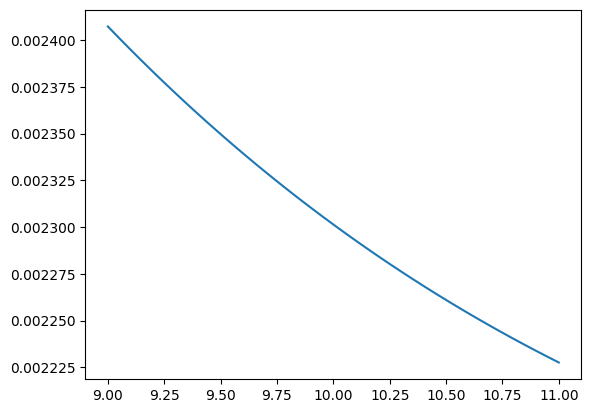

In [ ]:
plt.plot(R, u_MEF)

# Solução MHA

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_239/2655007107.py:78: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Deslocamento ($\mu m$)')


Constantes encontradas: A=0.0000526499999999993, B=0.0159266249999998


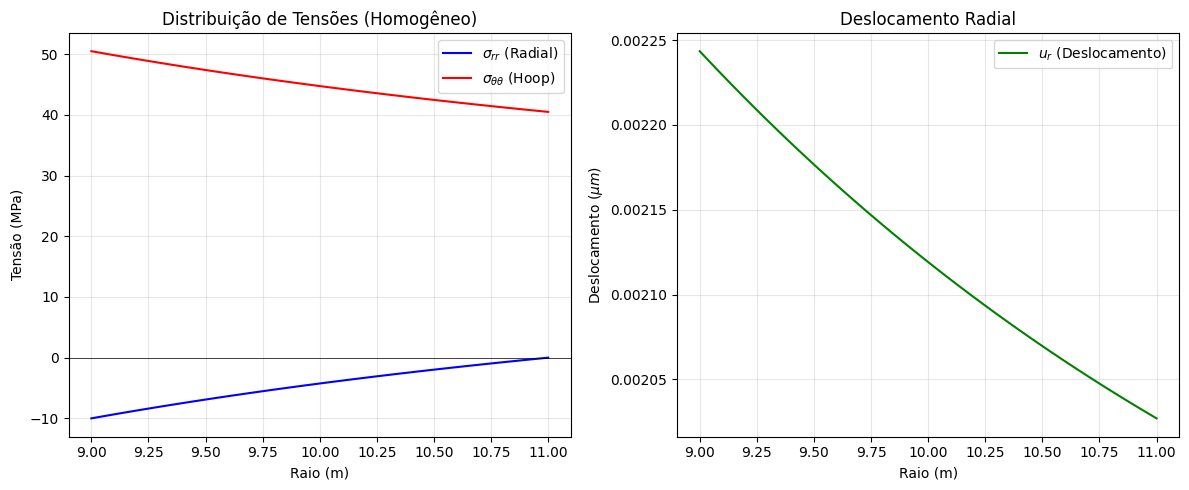

In [43]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

def solve_homogeneous_cylinder():
    # 1. Variáveis Simbólicas
    r = sp.symbols('r')
    A, B = sp.symbols('A B') # Apenas duas constantes agora

    # 2. Parâmetros Físicos (Apenas um material)
    R_int = 9.0
    R_ext = 11.0

    # Material Único (Ex: Aço)
    E_val = 200e9
    nu_val = 0.3

    # Cargas
    P_int_val = 10e6  # 10 MPa
    P_ext_val = 0.0   # 0 MPa

    # 3. Equações Constitutivas (Lei de Hooke em Cilíndricas)
    # Constantes de Lamé
    lmbda = (E_val * nu_val) / ((1 + nu_val) * (1 - 2 * nu_val))
    mu = E_val / (2 * (1 + nu_val))

    # Deformações (Kinematics)
    # u = A*r + B/r
    eps_rr = A - B/(r**2)
    eps_tt = A + B/(r**2)

    # Tensões (Constitutive)
    sig_rr = lmbda*(eps_rr + eps_tt) + 2*mu*eps_rr
    sig_tt = lmbda*(eps_rr + eps_tt) + 2*mu*eps_tt
    u_r    = A*r + B/r

    # 4. Sistema de Equações (Condições de Contorno)
    equations = []

    # BC 1: Pressão na parede interna
    # sigma_rr(R_int) = -P_int
    eq_in = sp.Eq(sig_rr.subs(r, R_int), -P_int_val)
    equations.append(eq_in)

    # BC 2: Pressão na parede externa
    # sigma_rr(R_ext) = -P_ext
    eq_out = sp.Eq(sig_rr.subs(r, R_ext), -P_ext_val)
    equations.append(eq_out)

    # 5. Solução
    sol = sp.solve(equations, (A, B))
    print(f"Constantes encontradas: A={sol[A]}, B={sol[B]}")

    # 6. Preparar para Plotagem
    func_srr = sp.lambdify(r, sig_rr.subs(sol), 'numpy')
    func_stt = sp.lambdify(r, sig_tt.subs(sol), 'numpy')
    func_u   = sp.lambdify(r, u_r.subs(sol), 'numpy')

    # Domínio radial
    radii = np.linspace(R_int, R_ext, 100)

    # --- Plotagem ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico 1: Tensões
    ax1.plot(radii, func_srr(radii)/1e6, 'b-', label=r'$\sigma_{rr}$ (Radial)')
    ax1.plot(radii, func_stt(radii)/1e6, 'r-', label=r'$\sigma_{\theta\theta}$ (Hoop)')
    ax1.set_xlabel('Raio (m)')
    ax1.set_ylabel('Tensão (MPa)')
    ax1.set_title('Distribuição de Tensões (Homogêneo)')
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfico 2: Deslocamento
    ax2.plot(radii, func_u(radii), 'g-', label=r'$u_r$ (Deslocamento)')
    ax2.set_xlabel('Raio (m)')
    ax2.set_ylabel('Deslocamento ($\mu m$)')
    ax2.set_title('Deslocamento Radial')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('cilindro_homogeneo.png') # Salva para exibir depois
    plt.show()

    return func_srr, func_stt, func_u

if __name__ == "__main__":
    sigmarr, sigmatt, u_MHA = solve_homogeneous_cylinder()

# Comparação MHA vs MEF

Constantes encontradas: A=0.0000526499999999993, B=0.0159266249999998


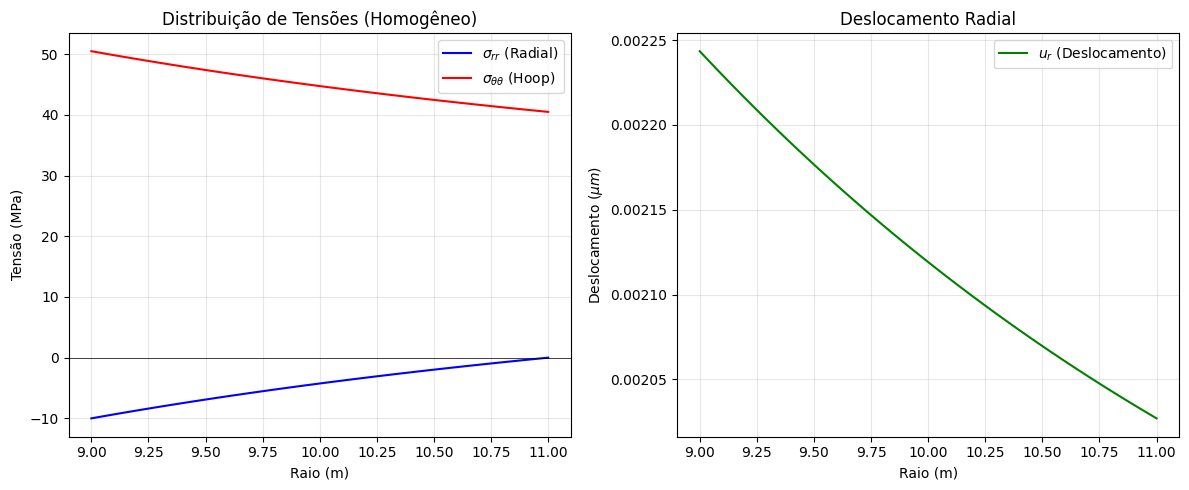

Simulação concluída! Arquivo salvo em 'resultado_cilindro/deslocamento.pvd'.


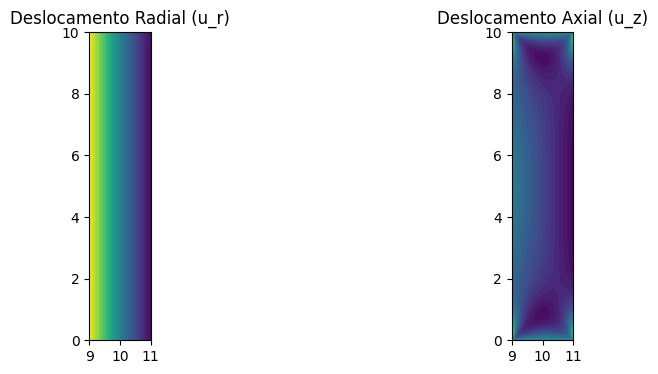

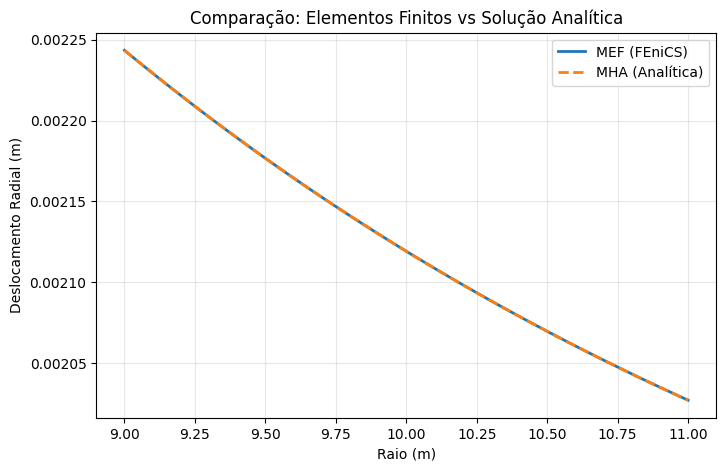

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Vamos pegar a função "fresquinha" direto da fonte para evitar lixo de memória
sigmarr, sigmatt, func_u_MHA = solve_homogeneous_cylinder()

# 1.1. Solução FEM
u_sol = simular_vaso_pressao()

# 2. Definir o domínio
Rint = 9.0
Rext = 11.0
R = np.linspace(Rint, Rext, 100)

# 3. Avaliar a solução do FEniCS (MEF)
# (Assumindo que a sua variável de solução do FEniCS se chama u_sol)
u_MEF_vals = [u_sol(r, 0)[0] for r in R]

# 4. Avaliar a solução Analítica (MHA)
# Agora sim, func_u_MHA é garantidamente uma função chamável!
u_MHA_vals = func_u_MHA(R)

# 5. Plotagem final
plt.figure(figsize=(8, 5))
plt.plot(R, u_MEF_vals, label='MEF (FEniCS)', linewidth=2)
plt.plot(R, u_MHA_vals, label='MHA (Analítica)', linestyle='--', linewidth=2)

plt.legend()
plt.xlabel('Raio (m)')
plt.ylabel('Deslocamento Radial (m)')
plt.title('Comparação: Elementos Finitos vs Solução Analítica')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Código a integrar https://gemini.google.com/share/be6eaadf4aac

# (Adicione isso na seção 2 do seu código FEniCS, logo após marcar a base)
# Marcamos o topo (z = H) com o ID 3
CompiledSubDomain("near(x[1], H)", H=H).mark(boundaries, 3)

# ... (Pule para a seção 5) ...

# Condições de Contorno
bc_base = DirichletBC(V.sub(1), Constant(0.0), boundaries, 2)

# NOVA: Trava o movimento vertical no topo também!
bc_topo = DirichletBC(V.sub(1), Constant(0.0), boundaries, 3)

# Resolva passando as duas restrições na lista
solve(a == L, u_sol, [bc_base, bc_topo])